In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np


In [2]:
file_path= "data (1).csv"
data = pd.read_csv(file_path)
X= data.drop(columns=['fail'])
y= data['fail']

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
n_components = 7 
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)


In [5]:
explained_variance_ratio = pca.explained_variance_ratio_
total_variance_explained = np.sum(explained_variance_ratio)


In [6]:
print("Explained Variance Ratio:", explained_variance_ratio)
print("Total Variance Explained:", total_variance_explained)


Explained Variance Ratio: [0.22688645 0.17972591 0.14855753 0.1110099  0.10496955 0.07001106
 0.06315933]
Total Variance Explained: 0.9043197278962516


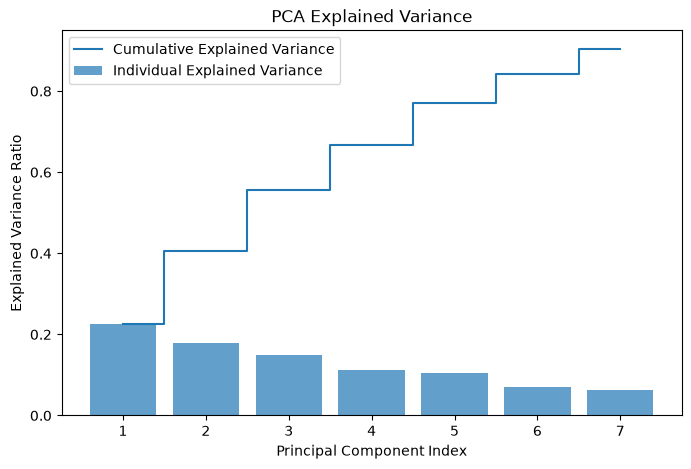

In [7]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, n_components + 1), explained_variance_ratio, alpha=0.7, align='center', label='Individual Explained Variance')
plt.step(range(1, n_components + 1), np.cumsum(explained_variance_ratio), where='mid', label='Cumulative Explained Variance')
plt.xlabel('Principal Component Index')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.legend(loc='best')
plt.show()


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy * 100:.7f}%")


Accuracy: 0.8571428571428571
Accuracy: 85.7142857%
